# 02 — Exploratory Data Analysis

## Scope discipline

Two kinds of analysis appear here and they are deliberately kept apart:

* **Corpus-level bookkeeping** (row counts, class balance, duplication)
  describes the dataset *as published*. Counting rows in a public dataset is not
  test-set peeking.
* **Distributional and relational analysis** — anything that could inform a
  modelling decision — is computed on the **training split only**. The validation
  and test splits are never inspected here.

Figures are produced by `src/eda.py` so that the notebook, the report and the
presentation all show the same images from the same code.

In [1]:
import sys, warnings
from pathlib import Path

# Make the repository root importable no matter where Jupyter was launched from.
ROOT = Path.cwd()
while not (ROOT / "src" / "config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)
warnings.filterwarnings("ignore", category=FutureWarning)

from src import config
print(f"Repository root : {ROOT}")
print(f"Random seed     : {config.RANDOM_STATE}")

Repository root : E:\AIM\AIM AI ML Capstone\AI_Capstone_Network_Intrusion_Detection
Random seed     : 42


In [2]:
def show(figure_name, caption=None):
    """Display a figure produced by the pipeline, or explain how to produce it."""
    path = config.FIGURES_DIR / f"{figure_name}.png"
    if path.exists():
        display(Image(filename=str(path)))
        if caption:
            display(Markdown(f"*{caption}*"))
    else:
        display(Markdown(
            f"> ⚠️ `figures/{figure_name}.png` not found. "
            "Run the pipeline stage noted above to generate it."))

In [3]:
from src import eda, preprocessing, data_loader

corpus = data_loader.load_corpus()
dedup, prep = preprocessing.prepare_corpus(verbose=True)
train, _, _ = preprocessing.split_corpus(dedup, verbose=True)

print(f"\nEDA below uses the TRAINING SPLIT ONLY: {len(train):,} records")

[preprocessing] loaded 257,673 rows
[preprocessing] duplicate feature vectors: 103,989 (40.4%)
[preprocessing] contradictory feature vectors: 414
[preprocessing] corpus after dedup=True: 153,684 rows
[preprocessing] class balance: {0: 0.5562, 1: 0.4438}


[preprocessing] train  92,210 rows (60.0%)  attack rate=0.4438
[preprocessing] val    30,737 rows (20.0%)  attack rate=0.4438
[preprocessing] test   30,737 rows (20.0%)  attack rate=0.4438

EDA below uses the TRAINING SPLIT ONLY: 92,210 records


## 1. Class balance — and what deduplication does to it

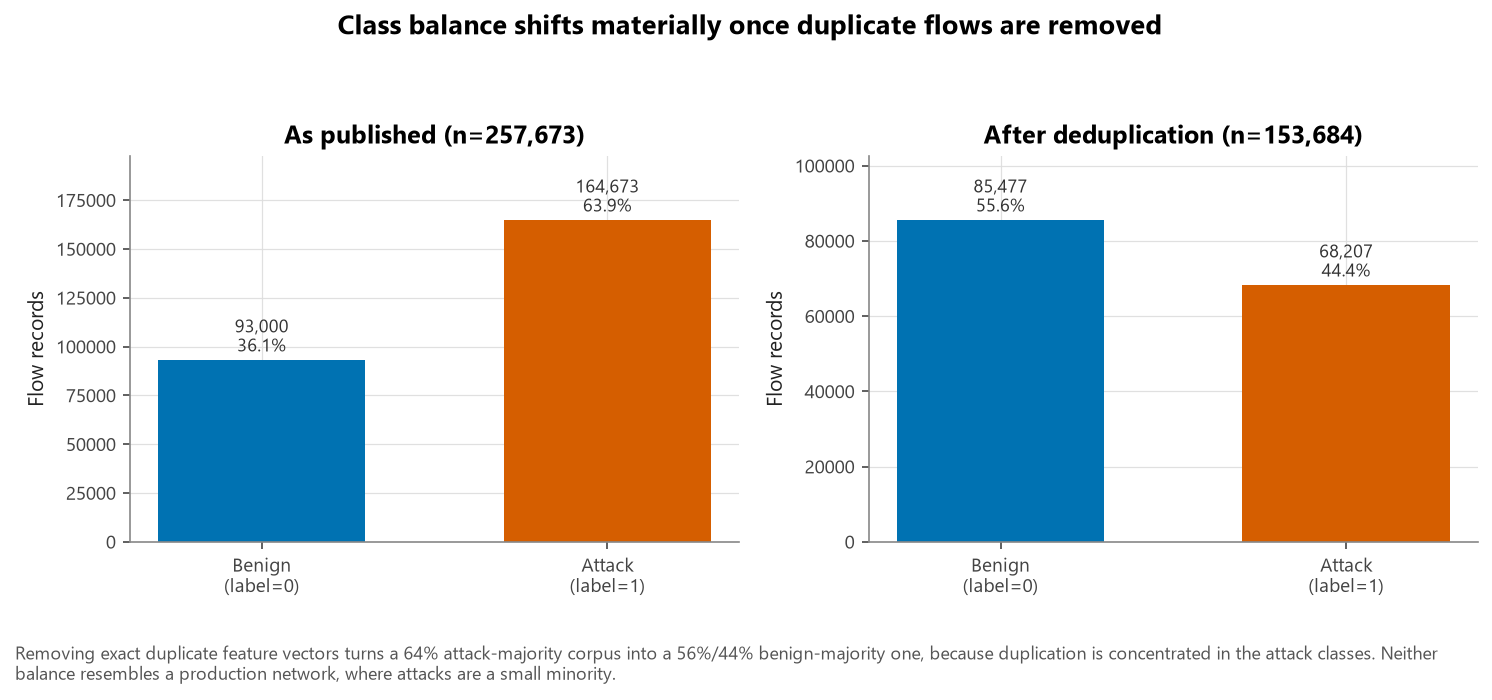

In [4]:
show("fig01_class_distribution")

Removing duplicate feature vectors turns a 63.9% attack-majority corpus into a
55.6% / 44.4% benign-majority one, because duplication is concentrated in the
attack classes.

**Neither balance resembles a production network.** In a real enterprise,
malicious flows are a fraction of a percent. This is the single most important
caveat attached to every precision figure later in the project.

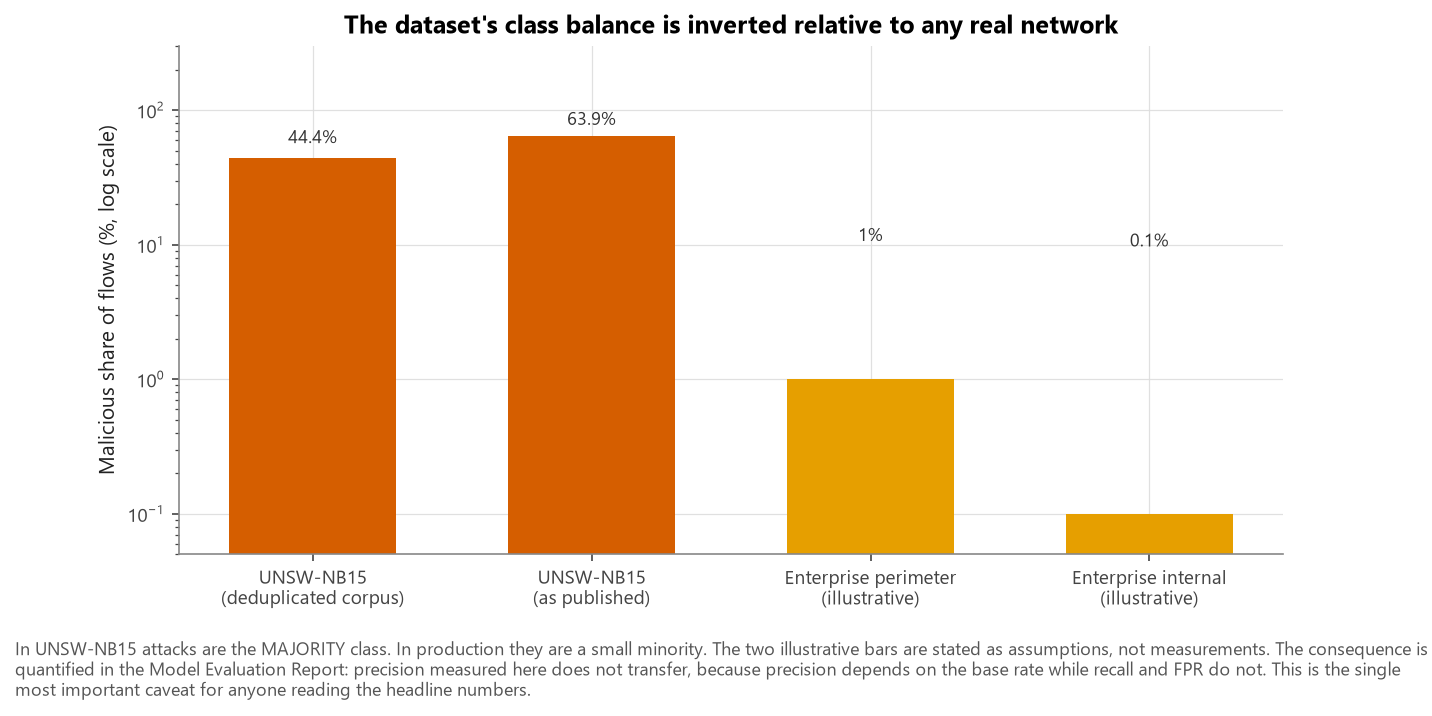

In [5]:
show("fig13_class_imbalance_context")

The gap is three orders of magnitude. Precision measured at a 44% base rate will
not survive a move to 0.1%. Recall and false-positive *rate* will.

## 2. Attack families

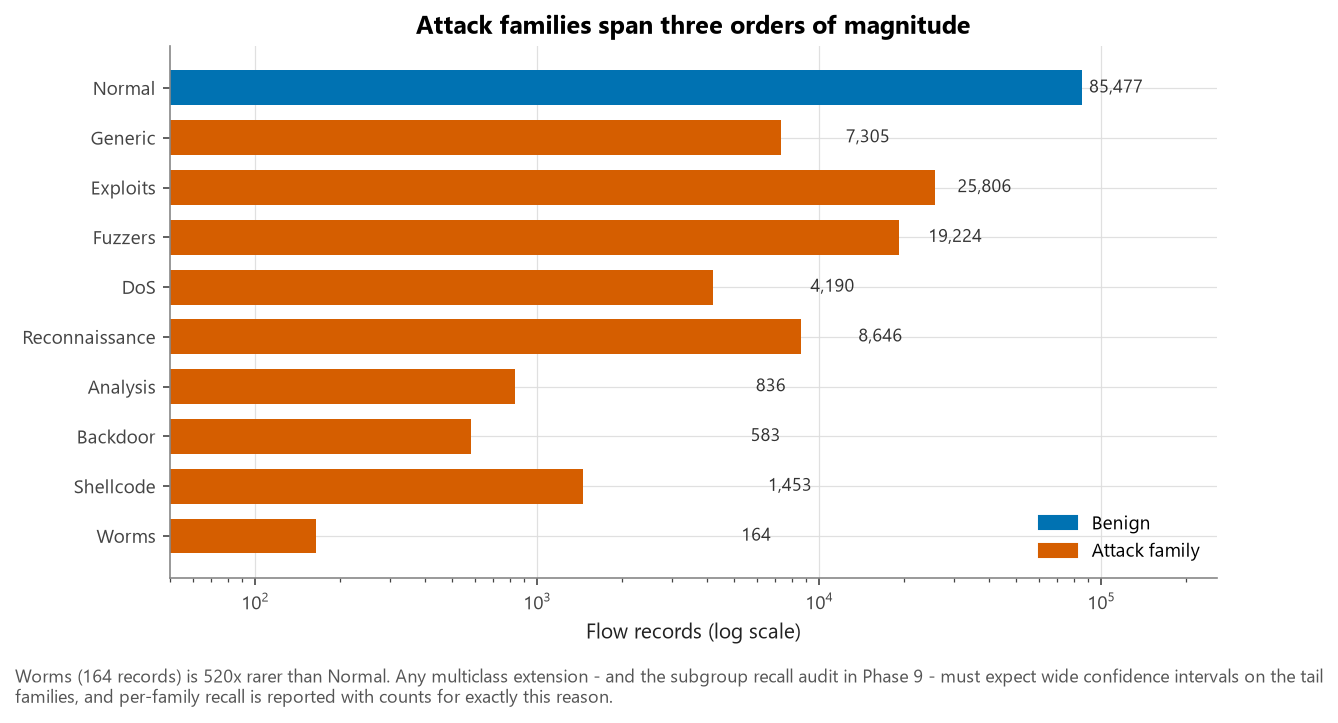

In [6]:
show("fig02_attack_category_distribution")

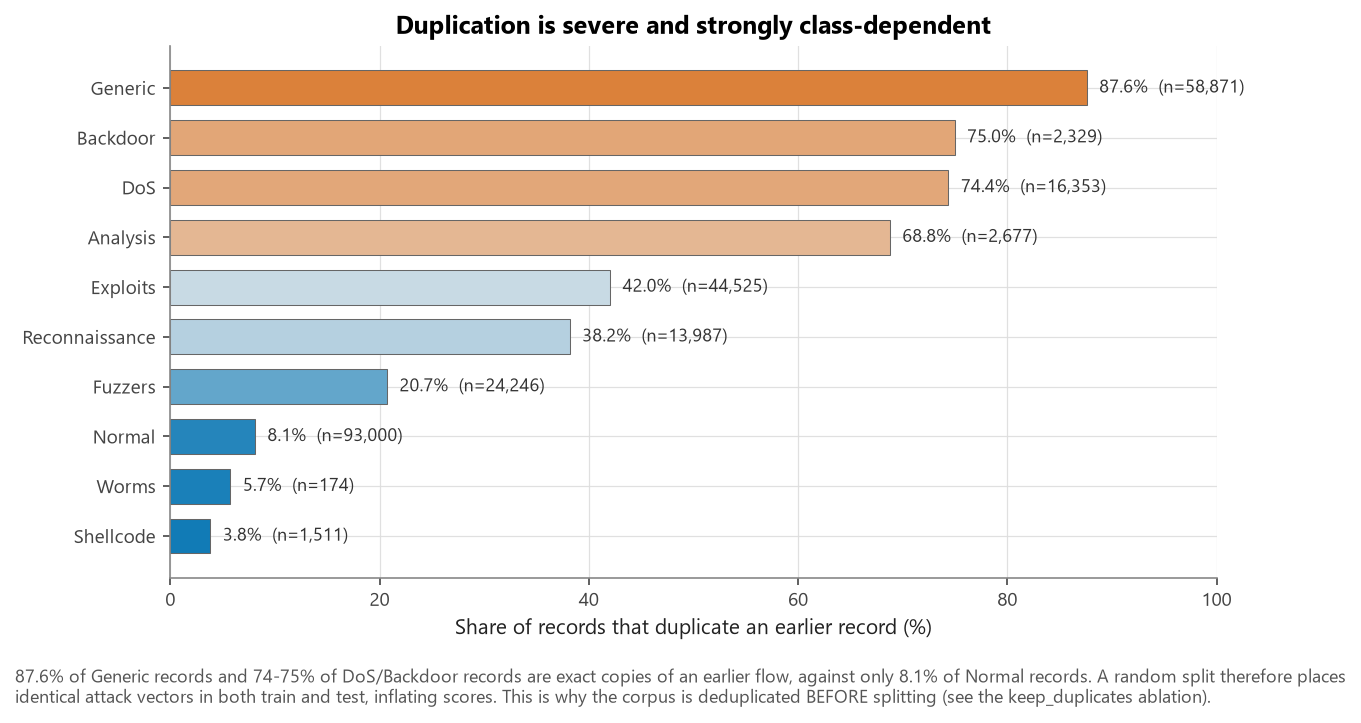

In [7]:
show("fig03_duplication_by_attack_category")

Families span three orders of magnitude, and duplication varies from 87.6%
(Generic) to 8.1% (Normal). Two consequences:

1. Rare families get wide confidence intervals — so every per-family metric in
   this project is reported **with its sample count**.
2. Families whose data was heavily duplicated contributed far fewer *distinct*
   training examples than their raw counts suggest. Their true training support
   is much smaller than it appears.

## 3. Categorical structure

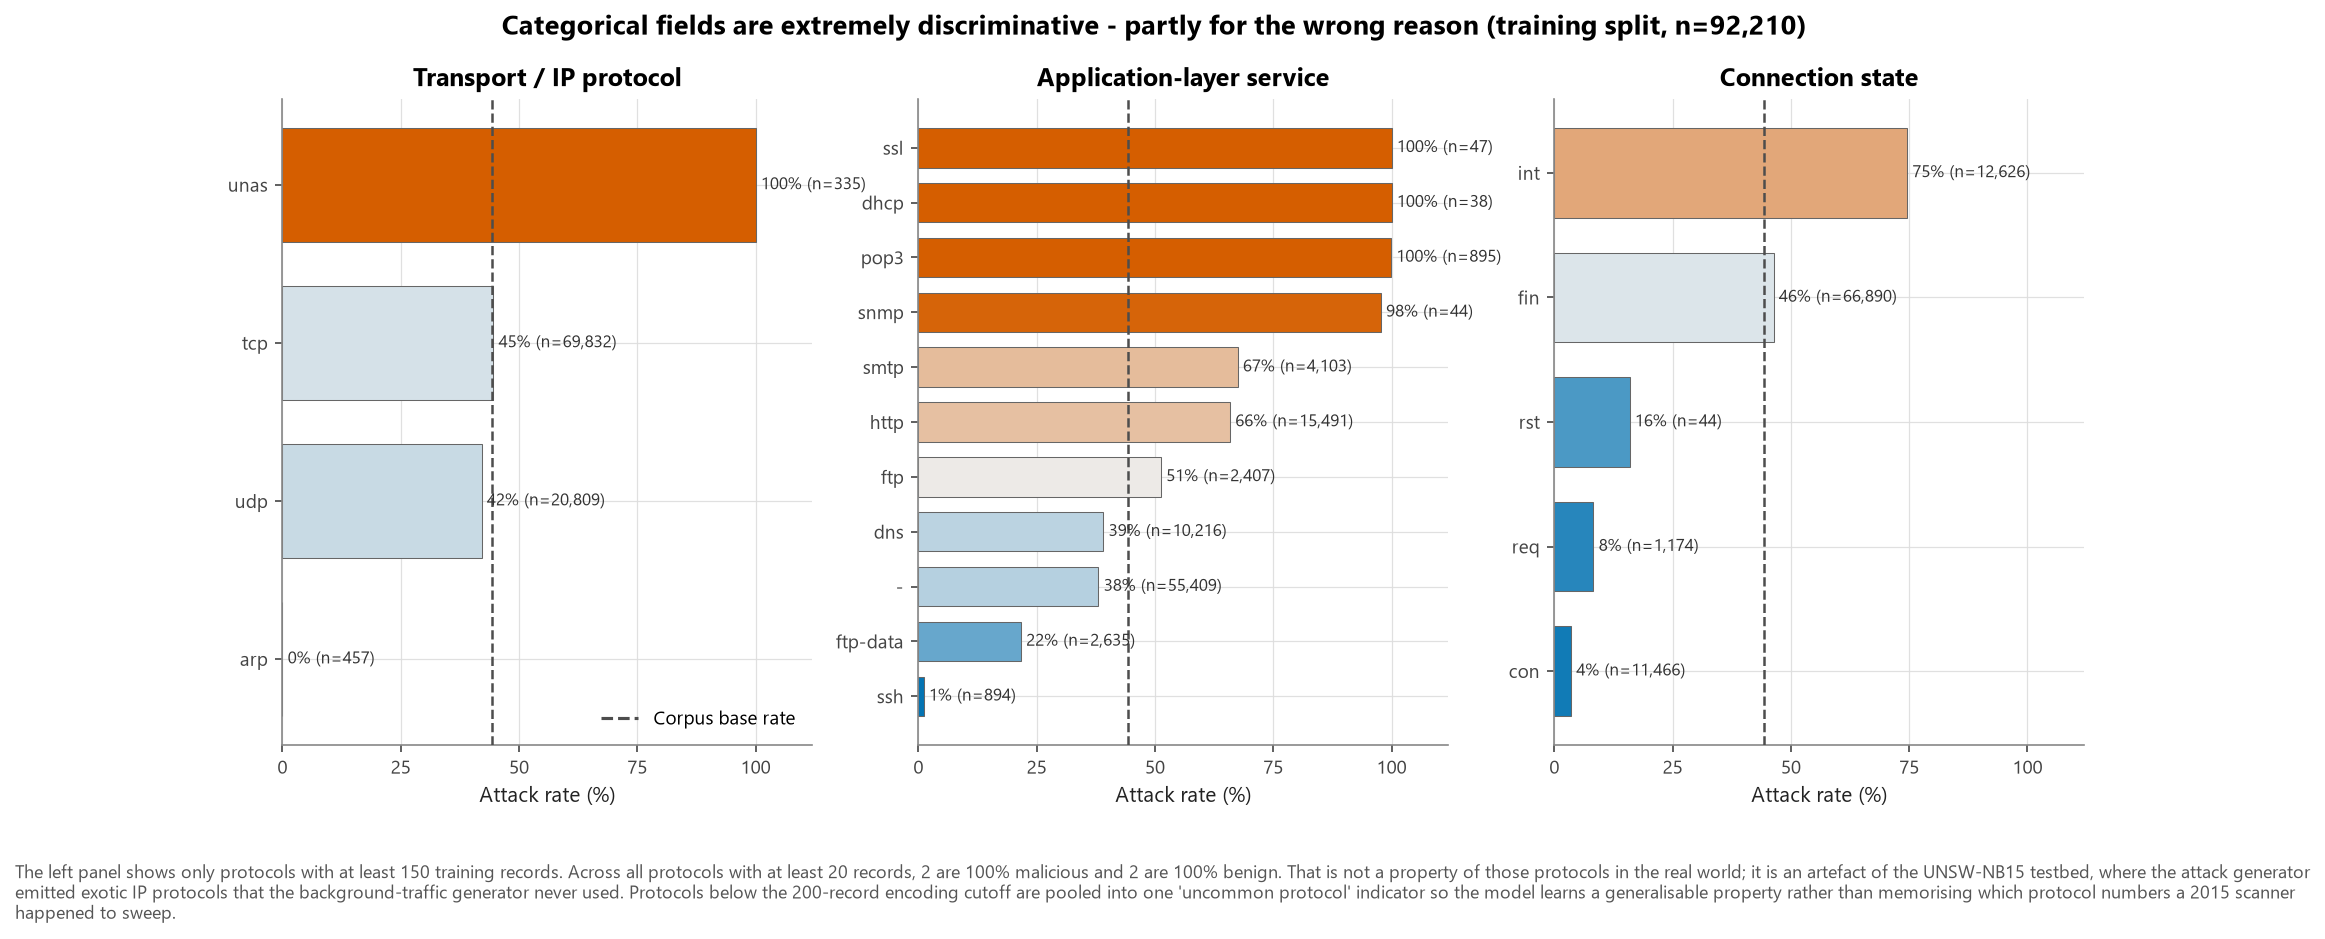

In [8]:
show("fig04_categorical_attack_rates")

In [9]:
for column in ("proto", "service", "state"):
    stats = (train.groupby(column, observed=True)["label"]
             .agg(records="size", attack_rate="mean")
             .query("records >= 50")
             .sort_values("attack_rate", ascending=False))
    print(f"\n=== {column} (levels with >= 50 training records) ===")
    display(stats.head(8).style.format({"records": "{:,}", "attack_rate": "{:.1%}"}))


=== proto (levels with >= 50 training records) ===


,records,attack_rate
proto,,
unas,335,100.0%
sctp,54,100.0%
ospf,137,64.2%
tcp,"69,832",44.6%
udp,"20,809",42.1%
arp,457,0.0%



=== service (levels with >= 50 training records) ===


,records,attack_rate
service,,
pop3,895,99.9%
smtp,"4,103",67.5%
http,"15,491",65.9%
ftp,"2,407",51.3%
dns,"10,216",39.1%
-,"55,409",38.1%
ftp-data,"2,635",21.7%
ssh,894,1.1%



=== state (levels with >= 50 training records) ===


,records,attack_rate
state,,
int,"12,626",74.5%
fin,"66,890",46.3%
req,"1,174",8.3%
con,"11,466",3.5%


### Interpretation

Several protocols are **100% malicious** and ARP is **100% benign**. That is not
a property of those protocols in the real world — it is an artefact of the
testbed, where the attack generator emitted exotic IP protocols that the
background-traffic generator never used.

**Design response:** rare protocol levels are pooled into a single "uncommon
protocol" indicator during encoding, so the model learns a generalisable
property rather than memorising which protocol numbers a 2015 scanner swept.

`state` is the one categorical whose signal is genuinely defensible: `int` (no
reply received) really is what scanning looks like on any network.

## 4. The TTL artefact — the most important EDA finding

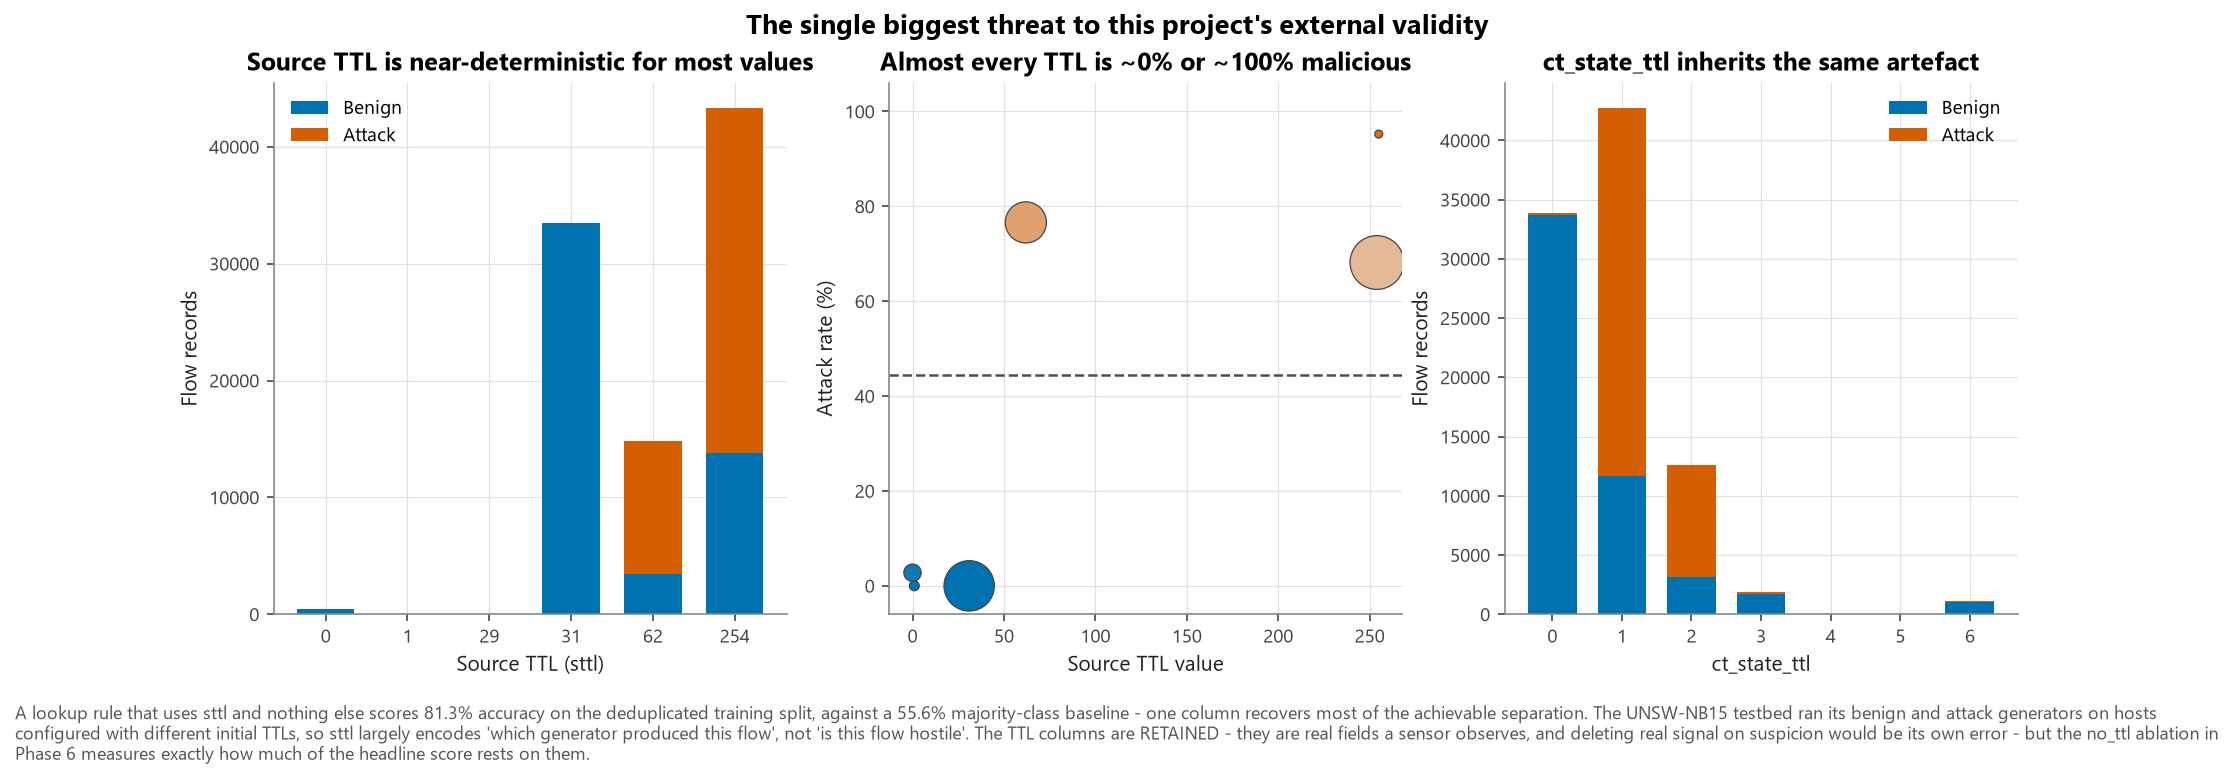

In [10]:
show("fig05_ttl_artifact")

In [11]:
lookup = train.groupby("sttl", observed=True)["label"].mean()
rule = (train["sttl"].map(lookup) > 0.5).astype(int)
accuracy = (rule == train["label"]).mean()
baseline = max(train["label"].mean(), 1 - train["label"].mean())

print(f"Accuracy of a lookup rule using sttl AND NOTHING ELSE : {accuracy:.4f}")
print(f"Majority-class baseline                               : {baseline:.4f}")
print(f"Lift from one column                                  : {accuracy - baseline:+.4f}")

Accuracy of a lookup rule using sttl AND NOTHING ELSE : 0.8127
Majority-class baseline                               : 0.5562
Lift from one column                                  : +0.2565


### Why this matters more than anything else in this notebook

One column recovers most of the achievable separation. The UNSW-NB15 testbed ran
its benign and attack generators on hosts configured with different initial TTL
values, so `sttl` largely encodes **which generator produced this flow**, not
**is this flow hostile**.

**The features are kept.** TTL is a real field a sensor observes and carries
genuine information (hop count, OS fingerprint). Deleting real signal on
suspicion would be its own methodological error.

**But its influence is measured, not assumed:**
- Notebook 06 quantifies it on the fitted model with SHAP.
- `python -m src.train --ablation no_ttl` retrains with all three TTL features
  removed, so we can see exactly what performance survives without them.

## 5. Numeric distributions

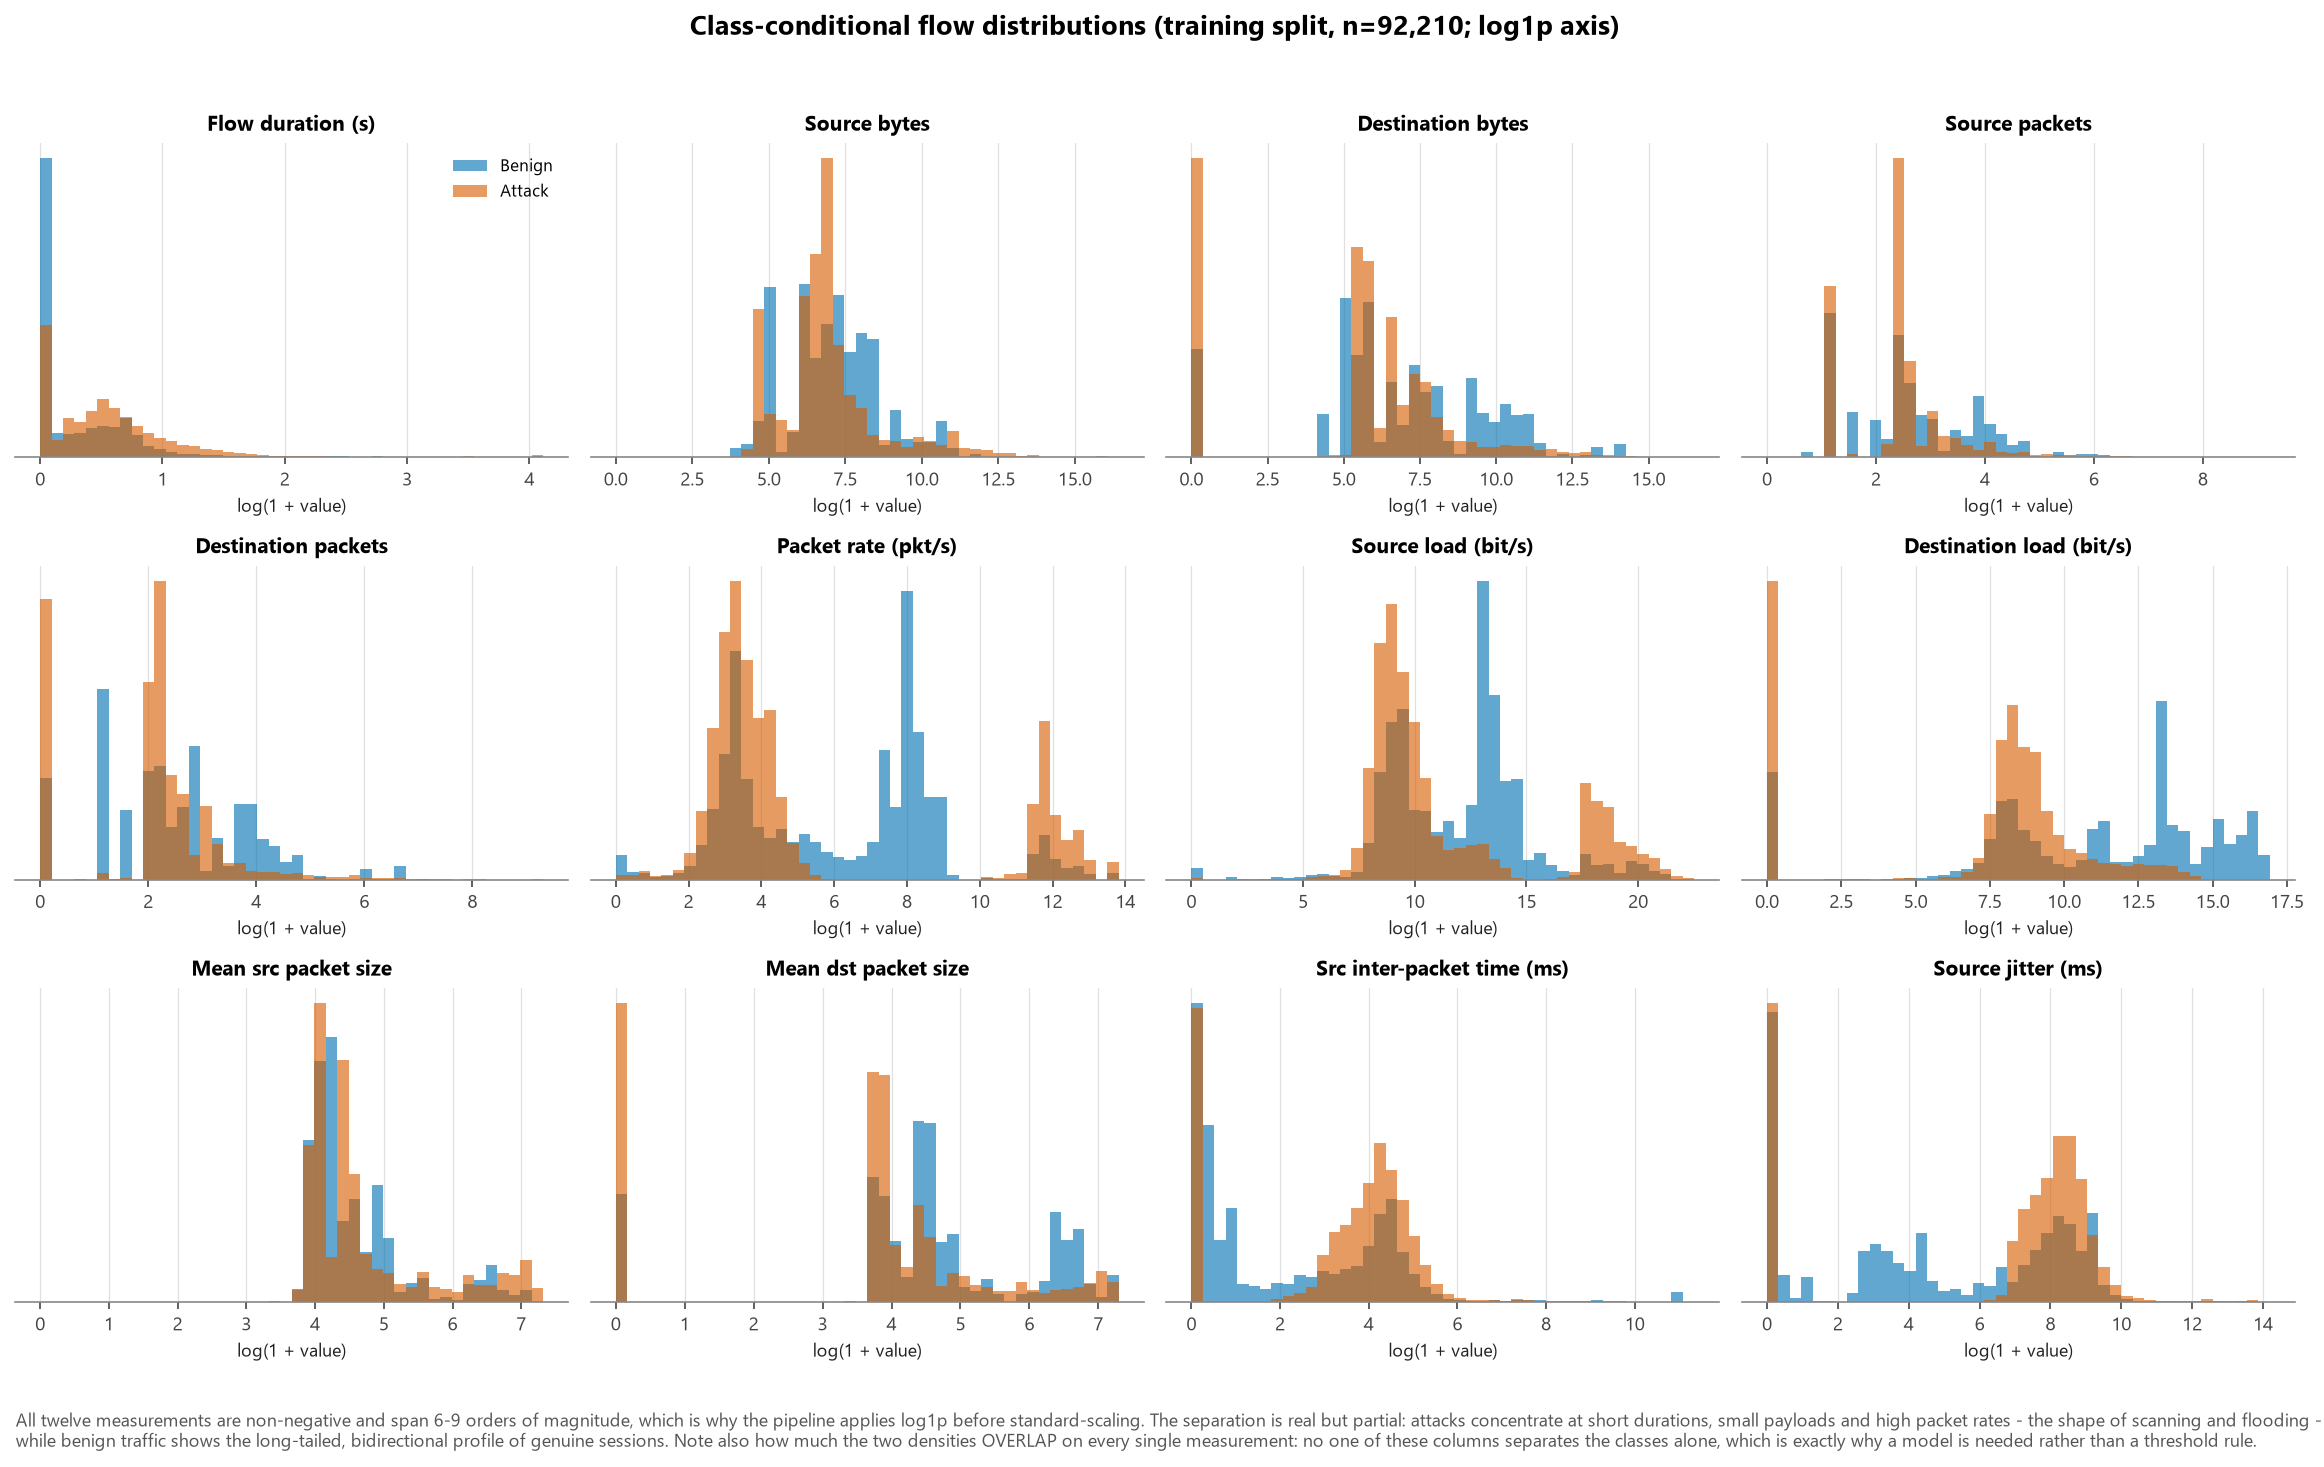

In [12]:
show("fig06_numeric_distributions_by_class")

In [13]:
heavy = ["dur", "sbytes", "dbytes", "rate", "sload", "sjit"]
display(train[heavy].describe(percentiles=[.01, .5, .99]).T
        .style.format("{:,.3g}"))
print("\nSkewness:")
print(train[heavy].skew().round(1).to_string())

,count,mean,std,min,1%,50%,99%,max
dur,9.22e+04,1.19,4.63,0,2e-06,0.383,20,60
sbytes,9.22e+04,1.36e+04,2.2e+05,46,78,978,1.36e+05,1.37e+07
dbytes,9.22e+04,2.36e+04,2e+05,0,0,546,5.48e+05,1.47e+07
rate,9.22e+04,3.01e+04,1.03e+05,0,0.67,72.4,5e+05,1e+06
sload,9.22e+04,4.29e+07,2.09e+08,0,272,4.67e+04,9.9e+08,5.99e+09
sjit,9.22e+04,6.03e+03,4.53e+04,0,0,1.49e+03,3.26e+04,1.46e+06



Skewness:
dur        9.6
sbytes    36.7
dbytes    38.8
rate       6.1
sload      9.8
sjit      18.0


Six to nine orders of magnitude on every counter, with skewness in the tens to
hundreds. This is why the pipeline applies `log1p` before standard-scaling:
monotonic (trees unaffected), defined at zero (so the 46.7% zero-byte reverse
directions survive), and reversible.

The separation between classes is real but partial — attacks concentrate at
short durations, small payloads and high packet rates, which is the shape of
scanning and flooding.

## 6. Outliers — analysed, not deleted

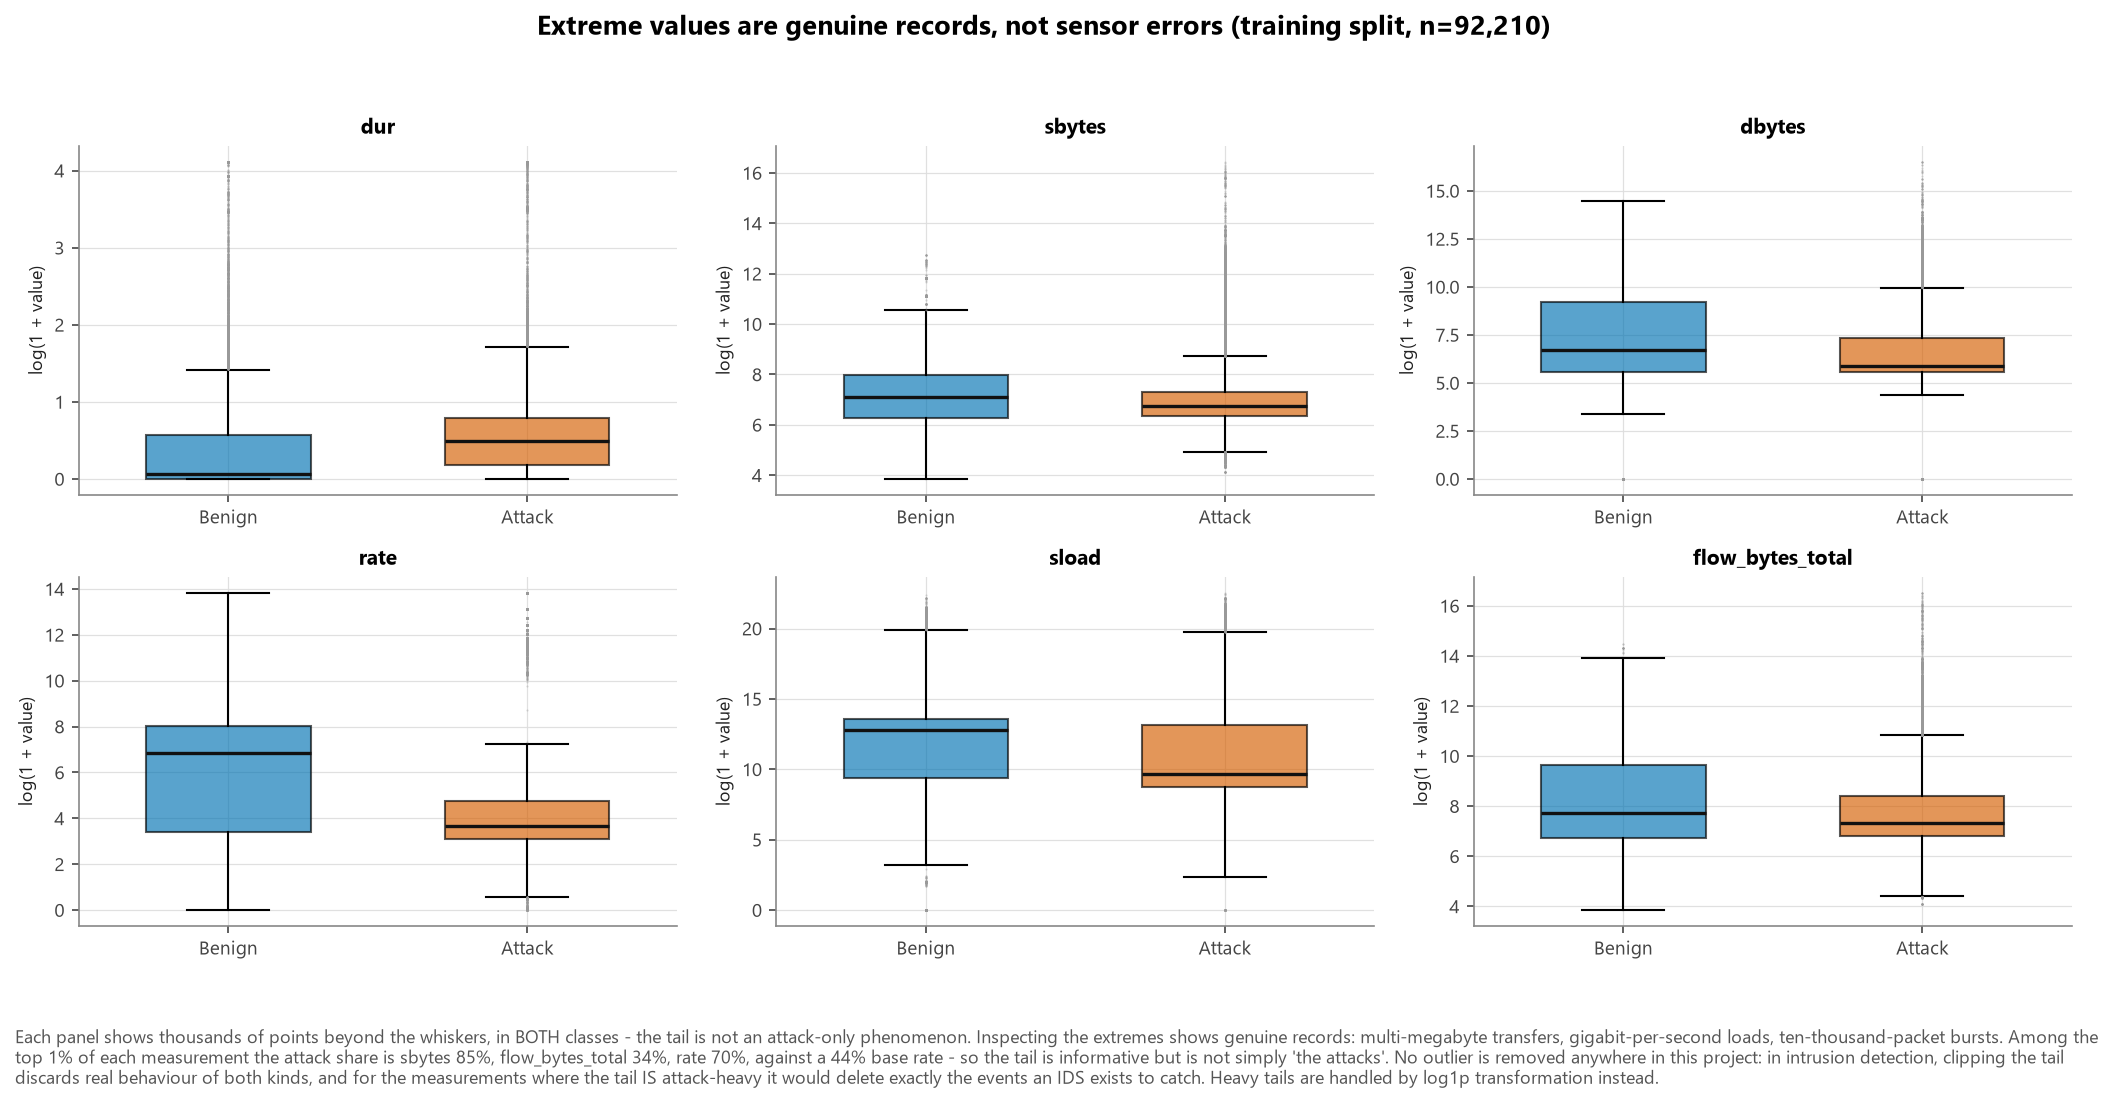

In [14]:
show("fig07_outlier_boxplots")

In [15]:
extreme = train.nlargest(8, "sbytes")[
    ["attack_cat", "proto", "service", "state", "dur", "sbytes", "dbytes", "spkts"]]
display(extreme)
print("\nThese are genuine records of genuine behaviour, not sensor errors.")

,attack_cat,proto,service,state,dur,sbytes,dbytes,spkts
70714,Exploits,tcp,-,con,59.932209,13677393,65274,10200
36571,Exploits,tcp,smtp,con,59.970360,12965233,62436,9616
88268,Exploits,tcp,smtp,con,59.819950,12029826,59288,9094
44839,Exploits,tcp,smtp,con,59.965153,11854358,58530,8882
52279,Exploits,tcp,smtp,con,59.949772,11063467,54180,8324
55067,DoS,tcp,smtp,con,59.983910,10678012,53254,8070
68473,Exploits,tcp,-,con,59.980972,10508068,52700,7990
21461,DoS,tcp,smtp,fin,56.846069,10386256,52420,7908



These are genuine records of genuine behaviour, not sensor errors.


### Decision: no outlier is removed anywhere in this project

In network telemetry the extreme values are disproportionately the attacks. A
14 MB transfer, a 5.99 Gbit/s load and a 10,646-packet burst are exactly the
events an IDS exists to catch. Clipping the tail would delete the signal.

The only values that would have been treated as erroneous are non-finite ones,
and the dataset contains none. Heavy tails are handled by **transformation**,
not deletion.

## 7. Redundancy among features

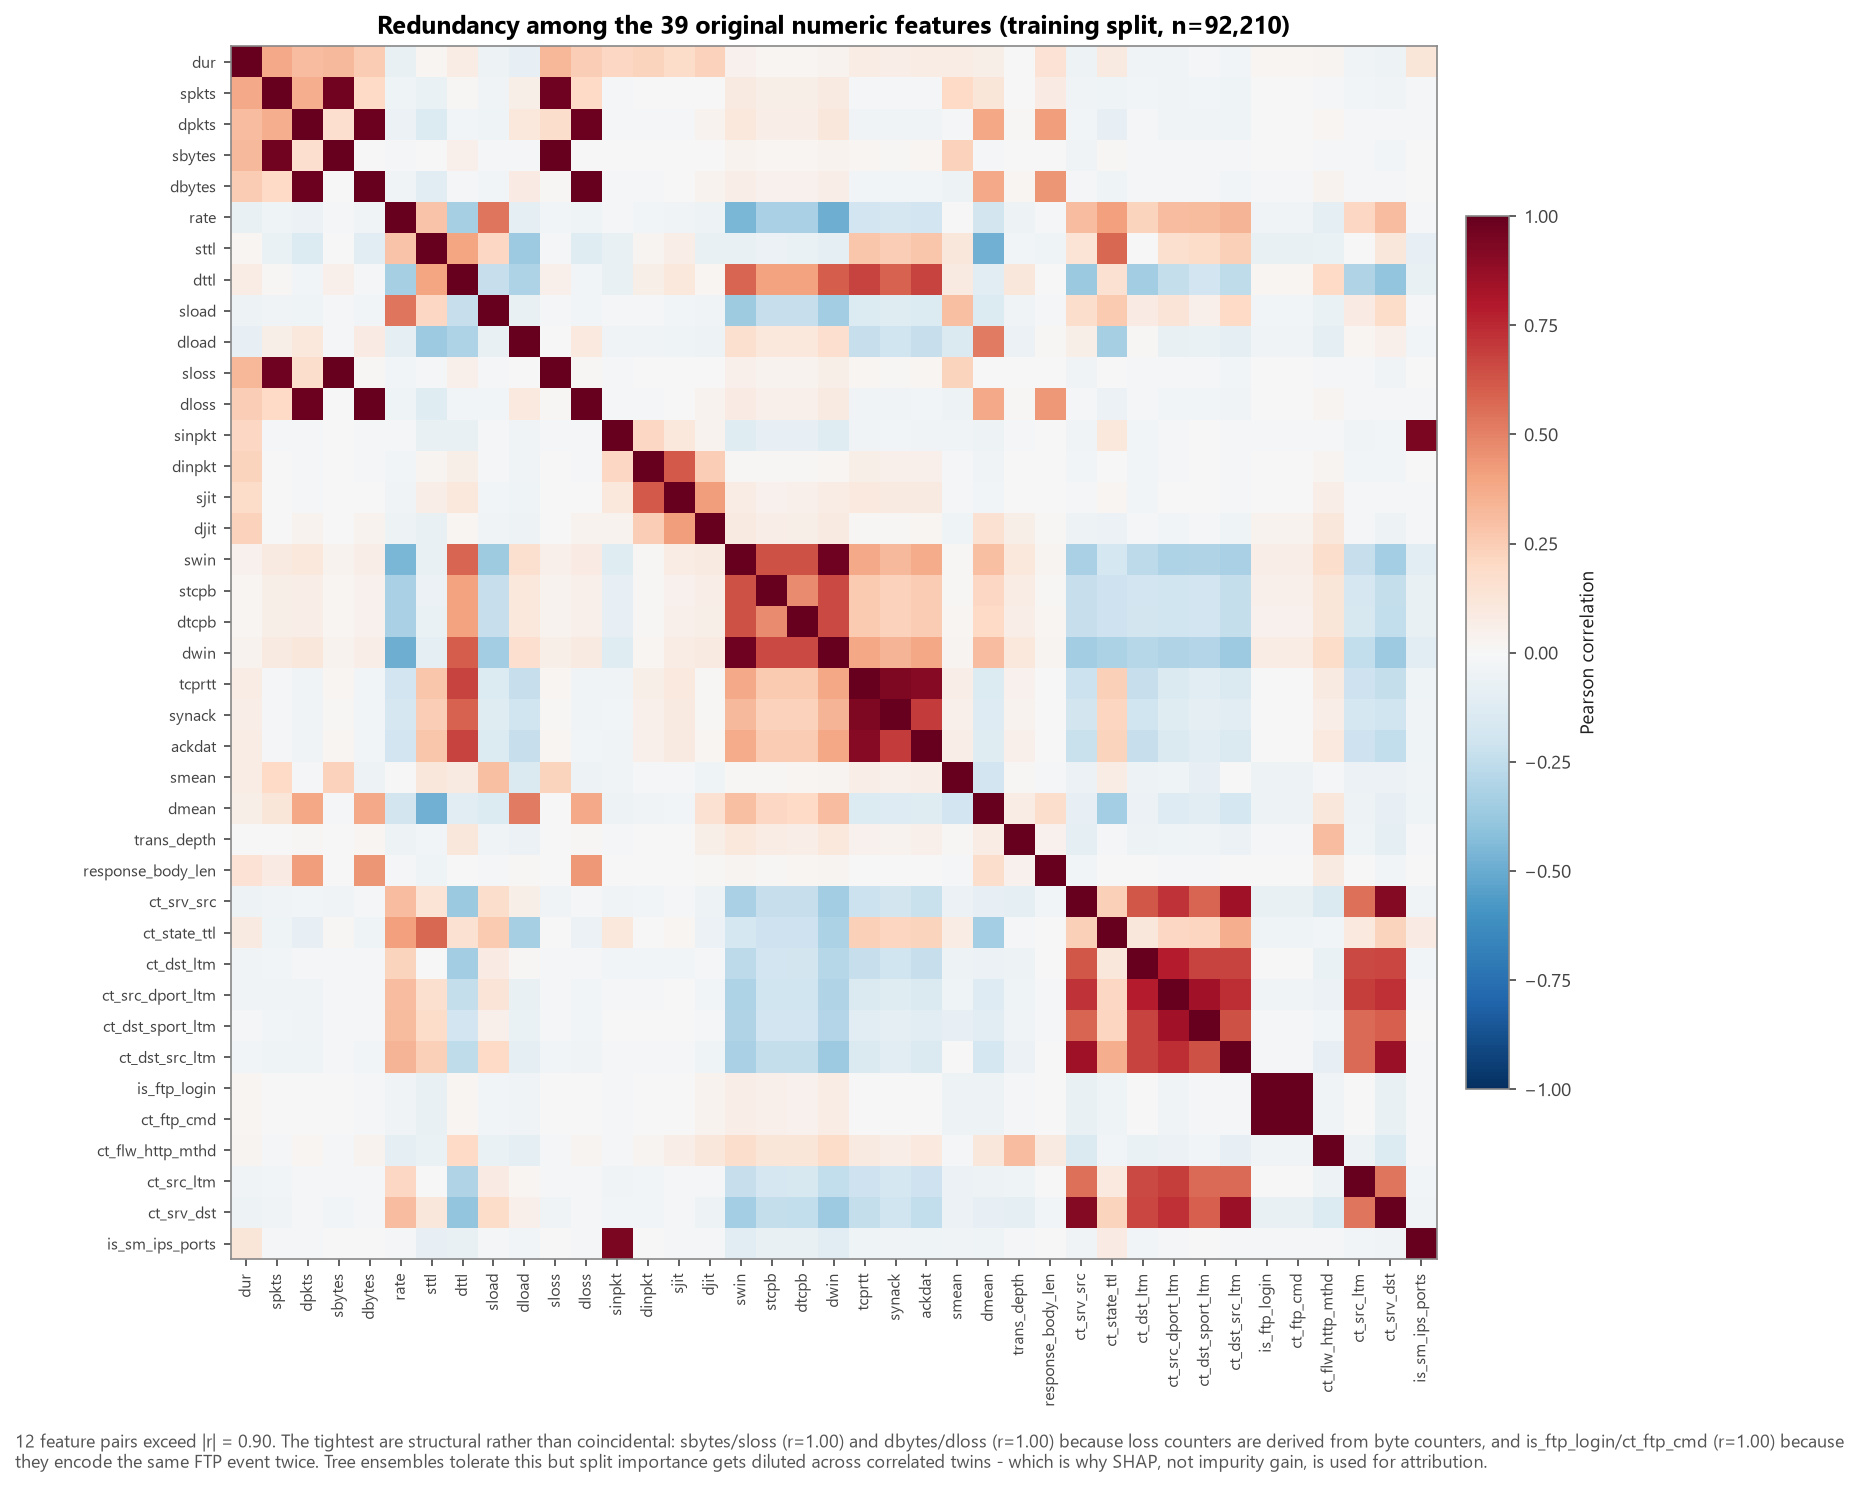

In [16]:
show("fig08_correlation_heatmap")

In [17]:
numeric = train.select_dtypes(include=[np.number]).drop(
    columns=["id", "label"], errors="ignore")
corr = numeric.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
pairs = upper[upper > 0.90].sort_values(ascending=False)

print(f"{len(pairs)} feature pairs exceed |r| = 0.90\n")
display(pairs.head(10).to_frame("abs_correlation").style.format("{:.4f}"))

12 feature pairs exceed |r| = 0.90



The tightest pairs are **structural**, not coincidental: `sbytes`/`sloss` and
`dbytes`/`dloss` because loss counters are derived from byte counters;
`is_ftp_login`/`ct_ftp_cmd` because they encode the same FTP event twice.

Two consequences:
- The design matrix is severely ill-conditioned, so logistic regression needs L2
  regularisation for stable coefficients.
- **SHAP, not impurity-based importance, is used for attribution** — impurity
  gain splits credit arbitrarily between correlated twins.

## 8. Feature signal and per-family fingerprints

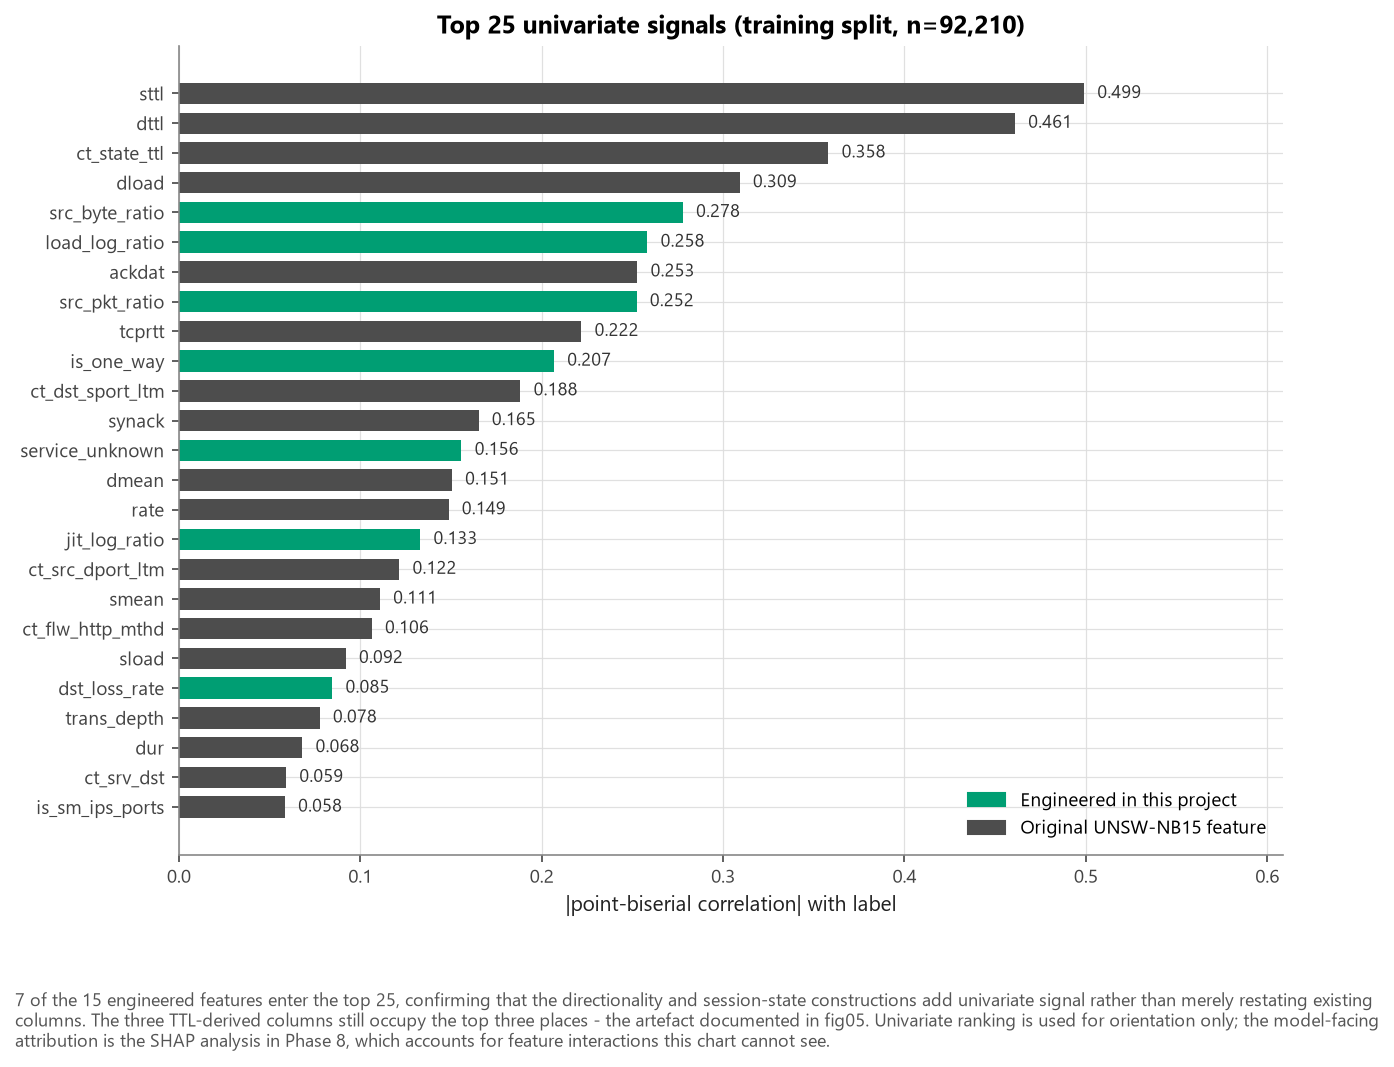

In [18]:
show("fig09_univariate_feature_ranking")

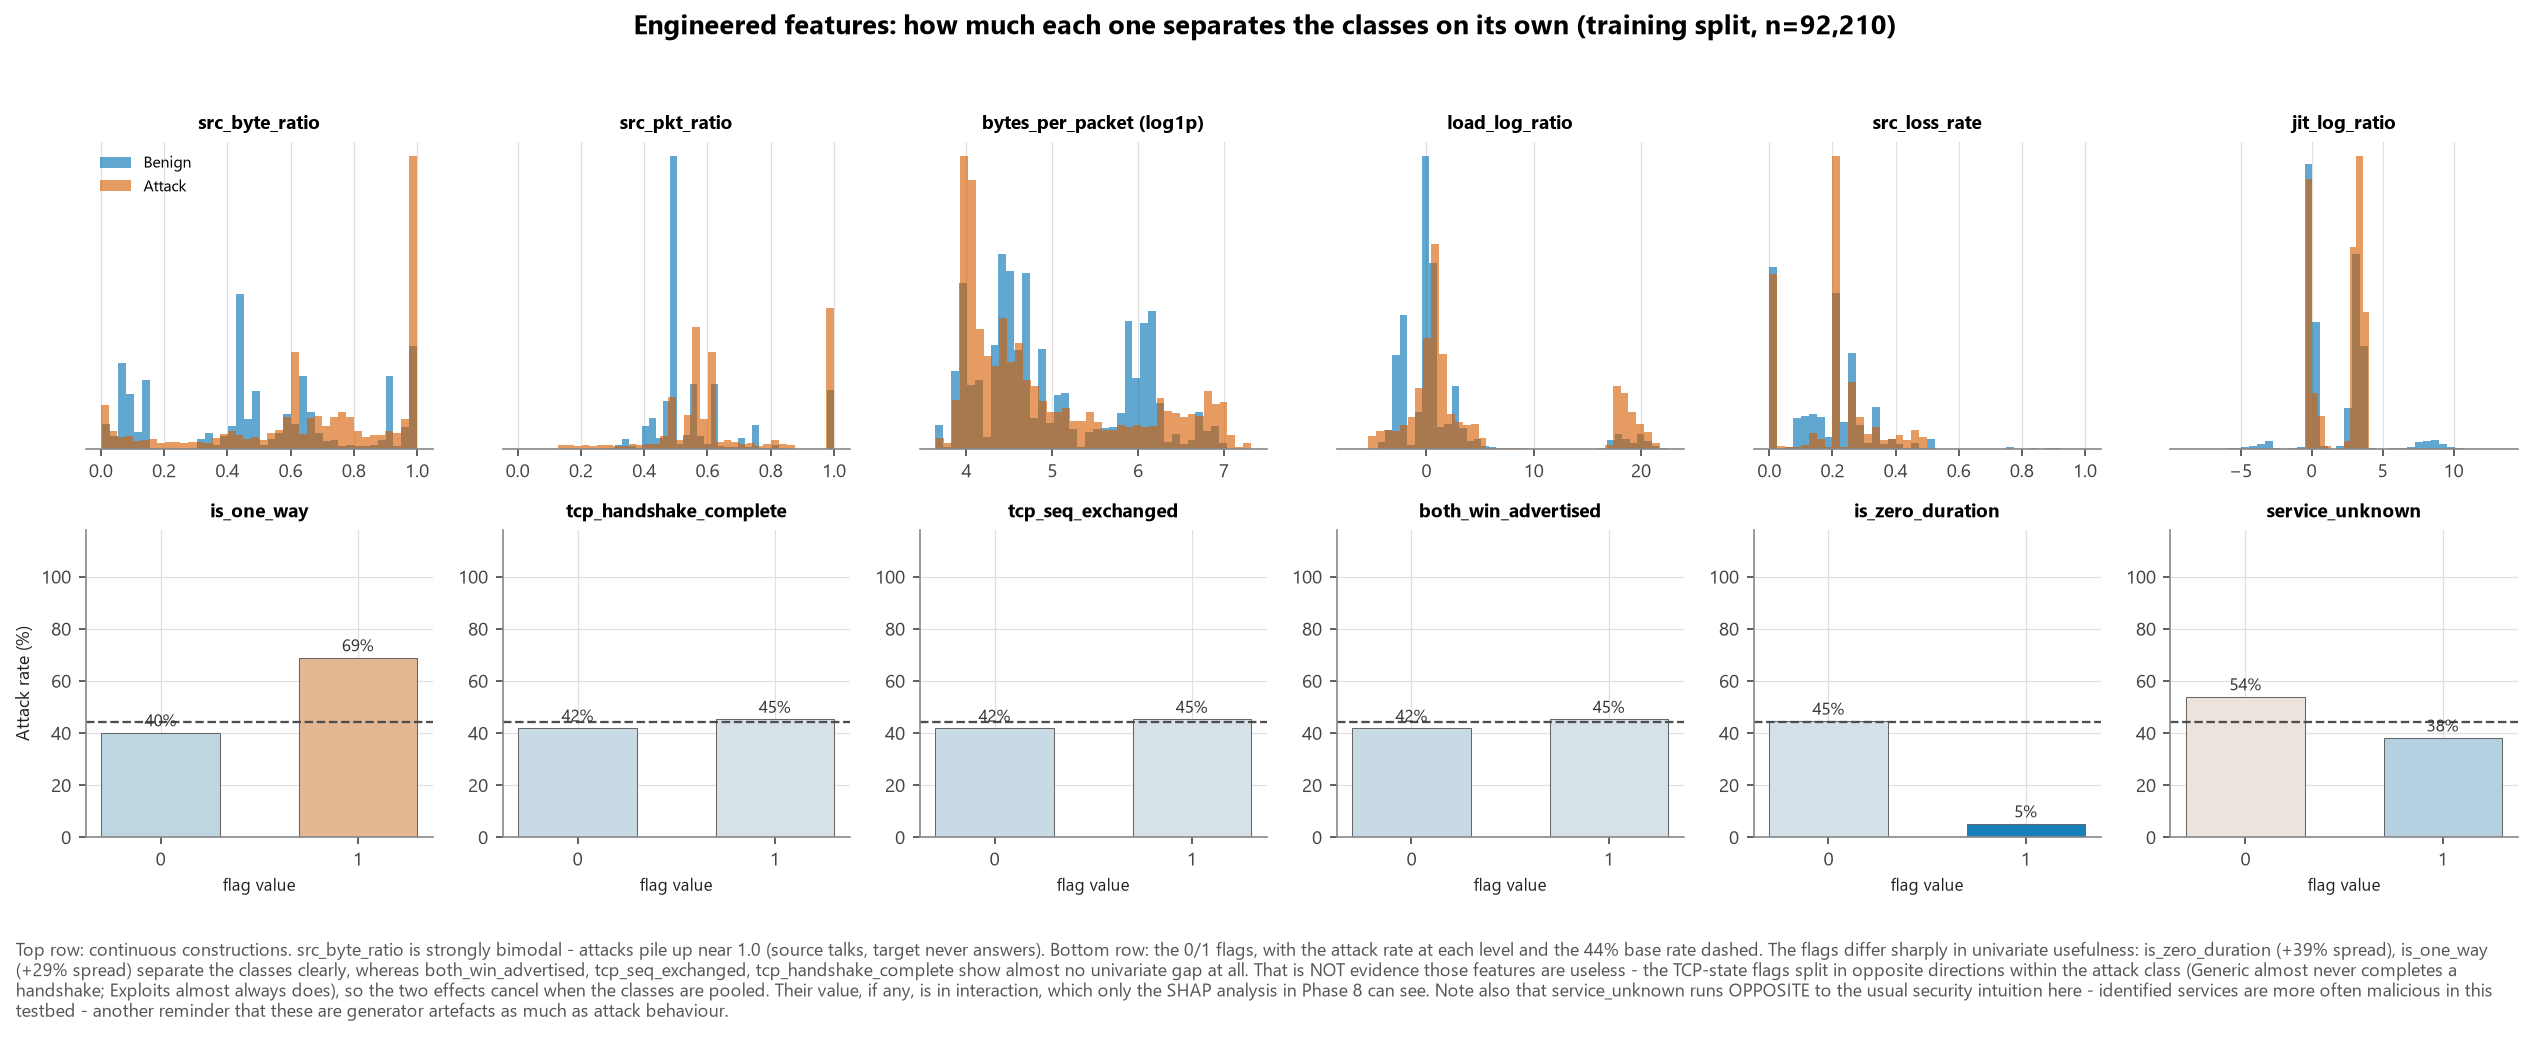

In [19]:
show("fig10_engineered_feature_separation")

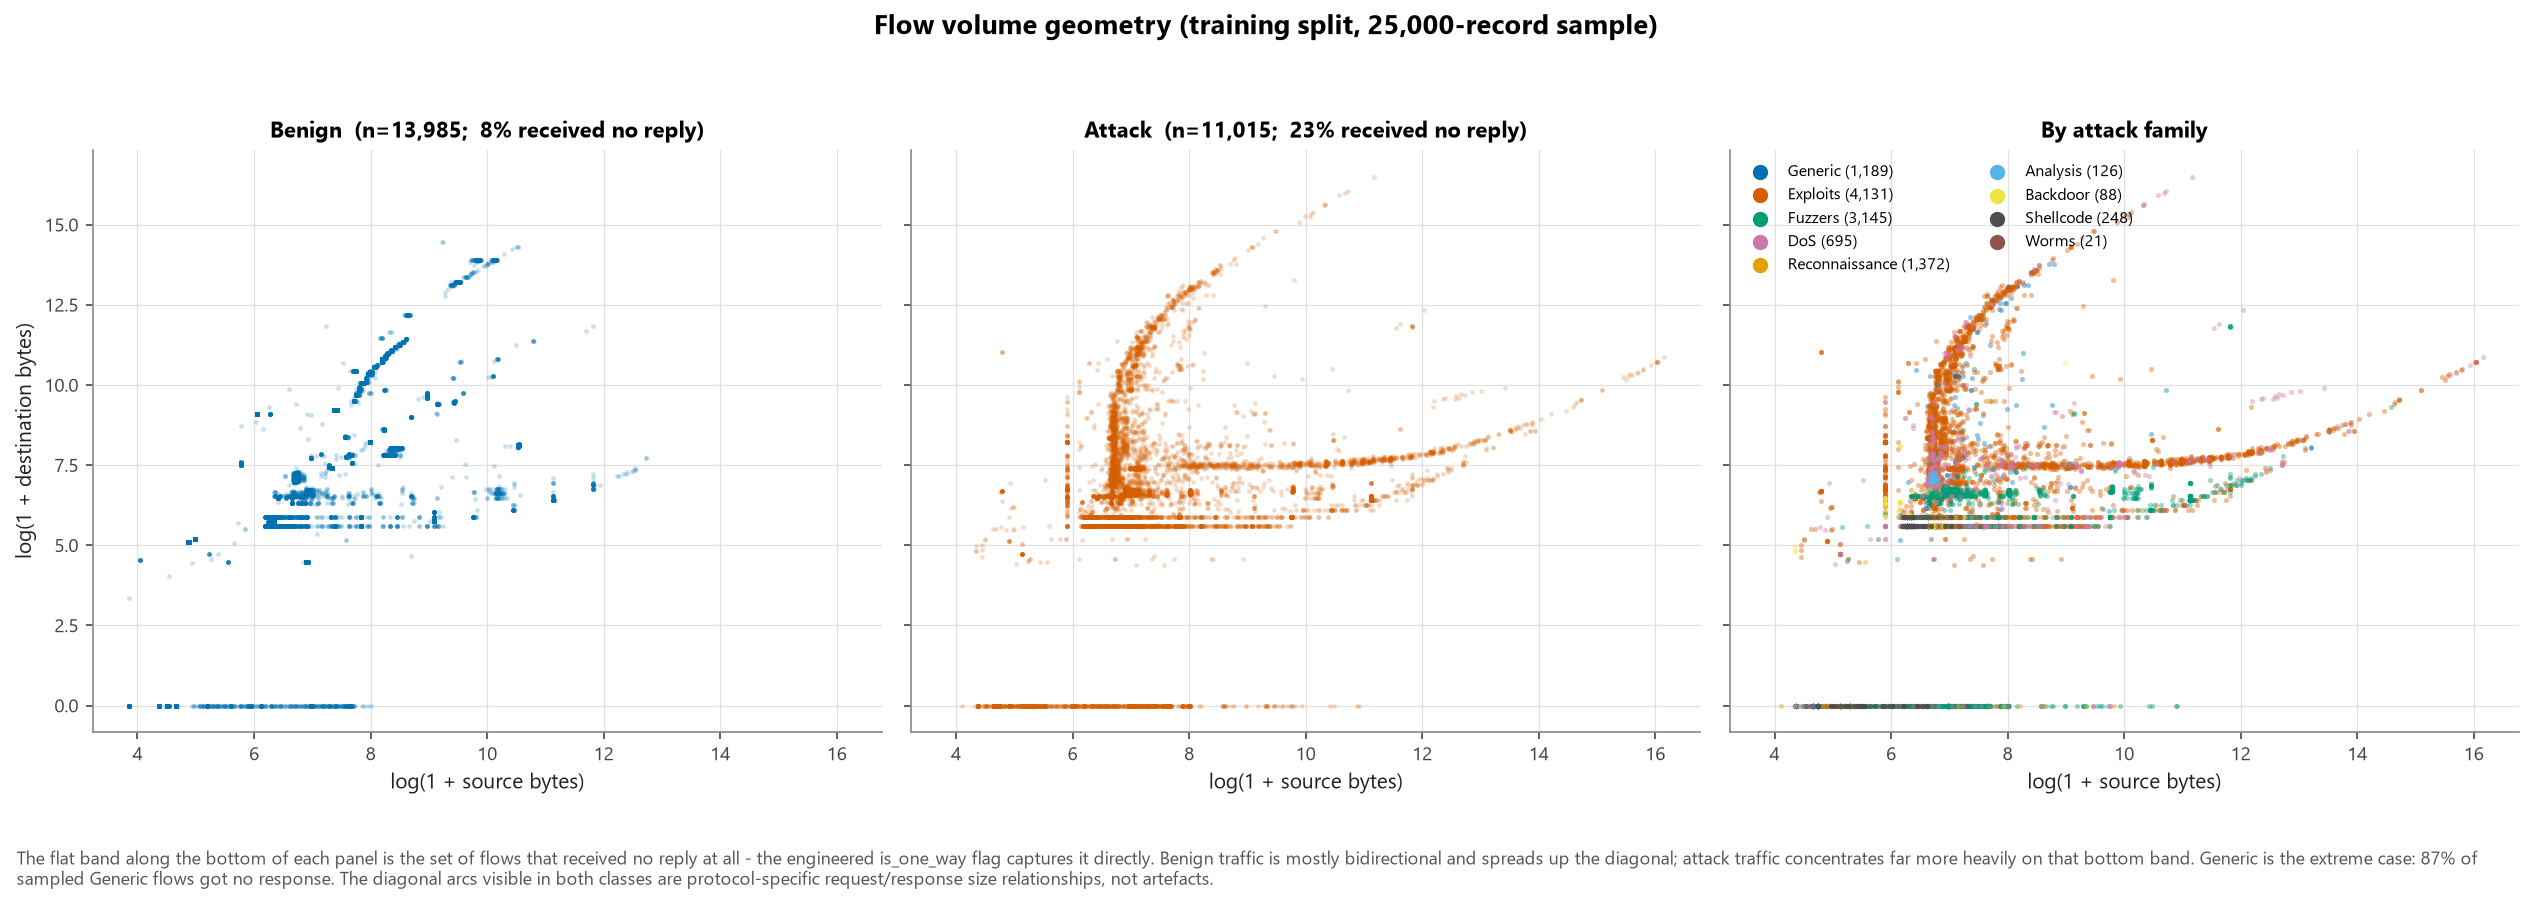

In [20]:
show("fig11_volume_scatter")

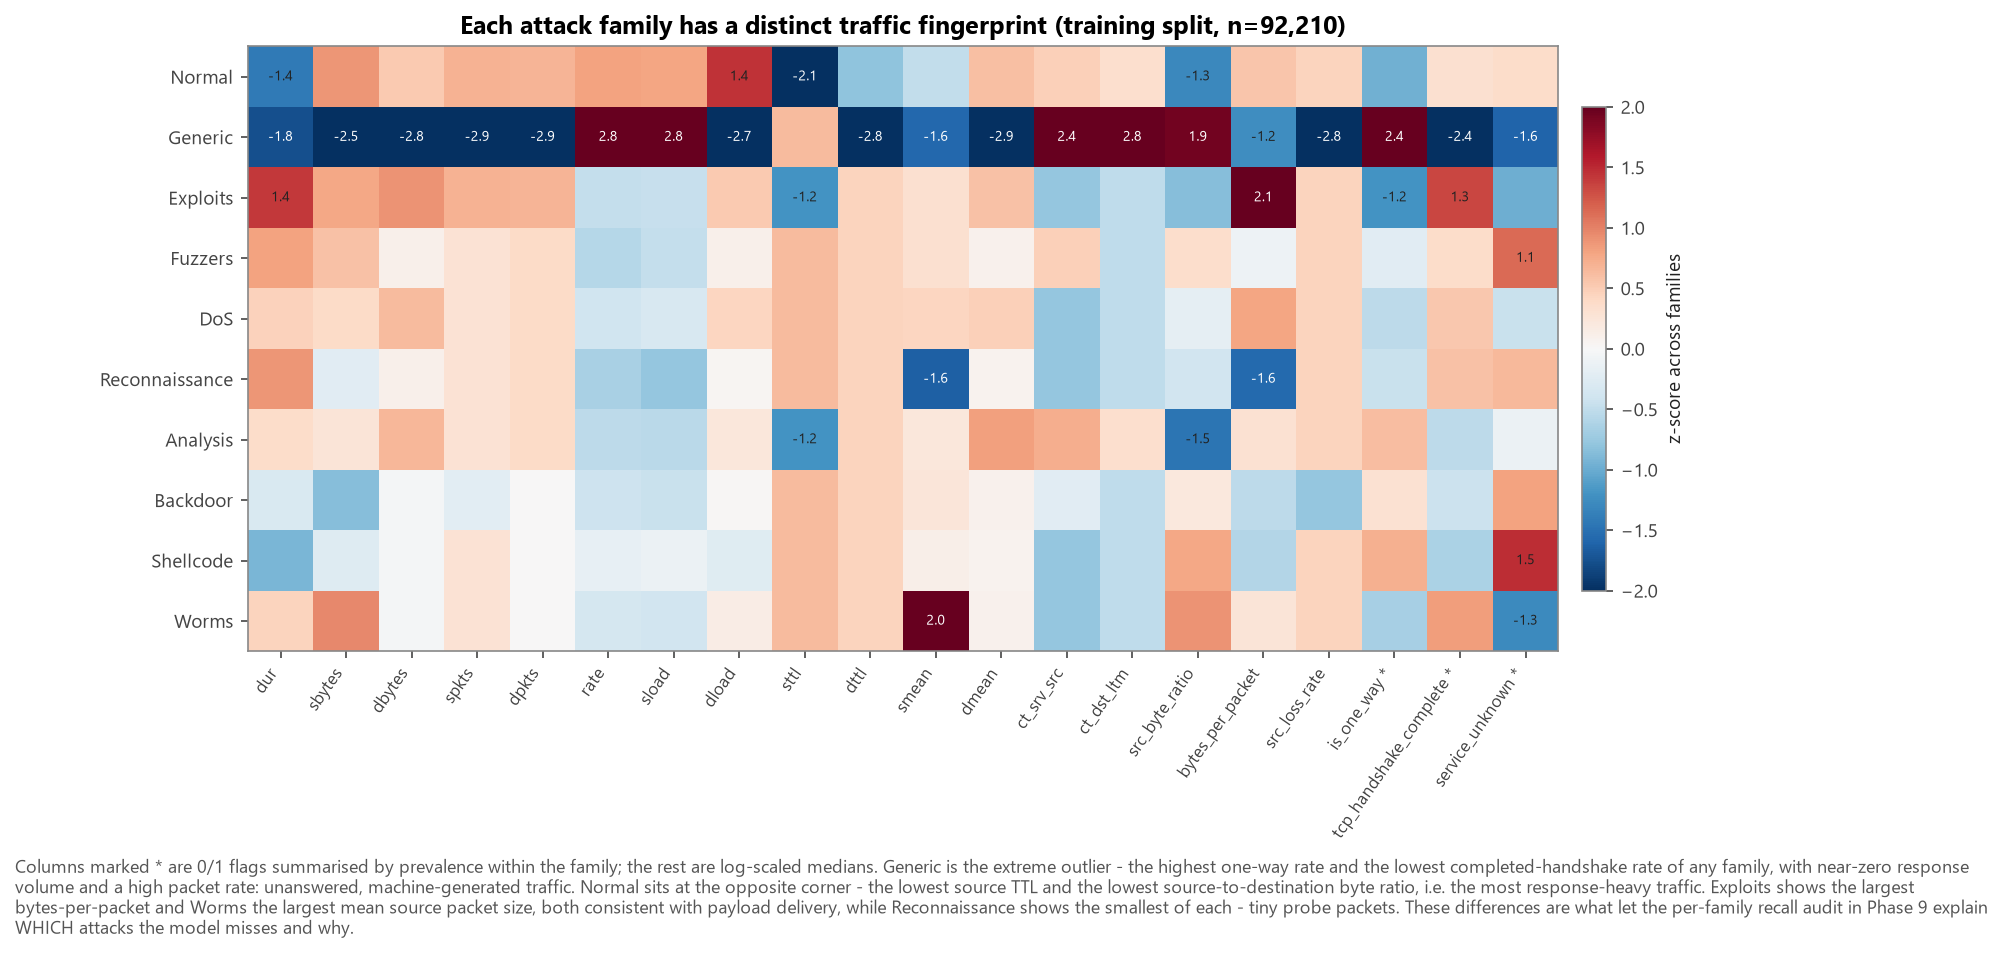

In [21]:
show("fig12_attack_family_profile")

### Interpretation

- The TTL family still occupies the top univariate ranks — consistent with
  section 4.
- Several engineered features enter the top 25, confirming they add signal
  rather than restating existing columns.
- `src_byte_ratio` is strongly **bimodal**: attacks pile up near 1.0 (source
  talks, target never answers).
- The horizontal band at `dbytes = 0` in the scatter is the 46.7% of flows that
  never received a reply — captured directly by the engineered `is_one_way` flag.
- Each attack family has a distinguishable fingerprint, which is what makes the
  per-family error analysis in notebook 06 interpretable rather than descriptive.

**Caveat:** univariate correlation cannot see interactions. It is used for
orientation; the model-facing attribution is the SHAP analysis in notebook 06.

---

## Findings that changed the project's design

| Finding | Design consequence |
|---|---|
| Duplication is class-correlated | Deduplicate **before** splitting; ablate to measure the cost |
| `sttl` alone reaches ~81% accuracy | Keep the features, quantify with SHAP, ablate with `no_ttl` |
| Exotic protocols are 100% malicious | Pool rare categories rather than memorise them |
| Outliers are genuine attacks | Transform with `log1p`, never clip |
| 12 feature pairs exceed \|r\| = 0.90 | Use SHAP rather than impurity importance |
| Six to nine orders of magnitude | `log1p` then standard-scale |
| Class balance is inverted vs production | Report recall and FPR as the transferable metrics |

**Next:** [`03_preprocessing_feature_engineering.ipynb`](03_preprocessing_feature_engineering.ipynb)